<a href="https://colab.research.google.com/github/AliefReefandi/Practical-Statistics-for-Data-Scientists/blob/main/Chapter_2_Data_and_Sampling_Distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 — Data and Sampling Distributions

## Practical Statistics for Data Scientists

Chapter ini membahas bagaimana data diperoleh melalui proses sampling dan bagaimana distribusi sampel dapat digunakan untuk memahami variasi suatu statistik.

Pembahasan meliputi random sampling, sample bias, sampling distribution, Central Limit Theorem, standard error, bootstrap, confidence interval, serta beberapa distribusi probabilitas.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

## 1. Gambaran Umum

Chapter 2 membahas data dan sampling distributions. Dalam analisis statistik, data yang tersedia biasanya hanya merupakan sebagian dari keseluruhan populasi.

Karena itu, proses sampling menjadi penting untuk mendapatkan data yang dapat mewakili populasi. Setelah sampel diperoleh, statistik seperti mean dapat dihitung untuk memperkirakan karakteristik populasi.

Chapter ini juga membahas bagaimana variasi sampel dapat dipahami melalui sampling distribution, Central Limit Theorem, standard error, dan bootstrap.

## 2. Tujuan Pembelajaran

Setelah mempelajari chapter ini, diharapkan dapat:

1. Memahami perbedaan population dan sample.
2. Memahami random sampling dan sample bias.
3. Menjelaskan selection bias.
4. Memahami sampling distribution.
5. Memahami Central Limit Theorem.
6. Menghitung standard error.
7. Memahami konsep bootstrap.
8. Membuat confidence interval menggunakan bootstrap.
9. Memahami distribusi normal dan standard normal.
10. Membaca QQ-Plot.
11. Mengenali distribusi dengan ekor panjang.
12. Memahami Student's t-distribution.
13. Memahami binomial, chi-square, F, Poisson, exponential, dan Weibull distribution.

## 3. Ringkasan Chapter

Sampling digunakan untuk mengambil sebagian data dari suatu populasi. Sampel yang baik harus memiliki karakteristik yang cukup mewakili populasi sehingga hasil analisis dapat digunakan untuk membuat perkiraan.

Chapter ini kemudian membahas sampling distribution, yaitu distribusi suatu statistik yang diperoleh dari banyak sampel. Konsep ini berhubungan erat dengan Central Limit Theorem dan standard error.

Bootstrap digunakan sebagai metode resampling untuk memperkirakan variasi suatu statistik tanpa harus memperoleh data baru dari populasi.

Selain itu, chapter ini membahas beberapa distribusi probabilitas seperti normal, t, binomial, chi-square, F, Poisson, exponential, dan Weibull.

## 4.1 Random Sampling and Sample Bias

### Random Sampling

Random sampling adalah proses memilih sebagian data dari suatu populasi secara acak. Setiap anggota populasi memiliki kesempatan untuk dipilih.

Dalam statistik:

- Population adalah keseluruhan data yang menjadi perhatian.
- Sample adalah sebagian data yang diambil dari population.

Sampling dapat dilakukan dengan dua cara:

1. With replacement
   Data yang sudah dipilih dikembalikan sehingga masih dapat dipilih kembali.

2. Without replacement
   Data yang sudah dipilih tidak dikembalikan sehingga tidak dapat dipilih kembali.

Random sampling digunakan untuk mendapatkan sample yang dapat mewakili karakteristik population.

### Sample Bias

Sample bias terjadi ketika sample tidak mewakili population secara tepat.

Hal ini dapat terjadi karena proses pemilihan sample tidak dilakukan secara acak atau terdapat kelompok tertentu yang lebih banyak terwakili.

Oleh karena itu, kualitas dan representativeness data juga penting, bukan hanya jumlah data.

In [ ]:
import pandas as pd

loan_data = pd.read_csv('loan_data.csv.gz')

loan_data.head()

,Unnamed: 0,status,loan_amnt,term,annual_inc,dti,payment_inc_ratio,revol_bal,revol_util,purpose,...,delinq_2yrs_zero,pub_rec_zero,open_acc,grade,outcome,emp_length,purpose_,home_,emp_len_,borrower_score
0,1,Charged Off,2500,60 months,30000,1.00,2.39320,1687,9.4,car,...,1,1,3,4.8,default,1,major_purchase,RENT,> 1 Year,0.65
1,2,Charged Off,5600,60 months,40000,5.55,4.57170,5210,32.6,small_business,...,1,1,11,1.4,default,5,small_business,OWN,> 1 Year,0.80
2,3,Charged Off,5375,60 months,15000,18.08,9.71600,9279,36.5,other,...,1,1,2,6.0,default,1,other,RENT,> 1 Year,0.60
3,4,Charged Off,9000,36 months,30000,10.08,12.21520,10452,91.7,debt_consolidation,...,1,1,4,4.2,default,1,debt_consolidation,RENT,> 1 Year,0.50
4,5,Charged Off,10000,36 months,100000,7.06,3.90888,11997,55.5,other,...,1,1,14,5.4,default,4,other,RENT,> 1 Year,0.55


4.1.1 Melihat Population

Kita menggunakan income dari dataset loan.

In [ ]:
loans_income = pd.read_csv('loans_income.csv').squeeze('columns')

loans_income.head()

,x
0,67000
1,52000
2,100000
3,78762
4,37041


In [ ]:
len(loans_income)

50000

In [ ]:
loans_income.describe()

,x
count,50000.00000
mean,68760.51844
std,32872.03537
min,4000.00000
25%,45000.00000
50%,62000.00000
75%,85000.00000
max,199000.00000


4.1.2 Random Sampling

Sekarang kita coba mengambil 10 data secara acak.

In [ ]:
sample = loans_income.sample(10, random_state=42)

sample

,x
33553,92000
9427,50000
199,40000
12447,95000
39489,135000
42724,70000
10822,100000
49498,80000
4144,26300
36958,100000


In [ ]:
#Kalau kita menjalankan:
loans_income.sample(10)

,x
24486,63600
44923,62000
30537,68500
4613,20400
8775,48000
25682,87000
47758,60000
3386,74800
12977,45000
8900,26500


In [ ]:
#kemudian menjalankannya lagi:

loans_income.sample(10)

,x
4002,120000
31033,88500
26510,133000
25670,24000
18792,50000
23499,29120
23418,108000
45455,85000
27623,95000
46517,52000


hasilnya bisa berbeda.

Itulah sifat random sampling.

4.1.3 Sampling dengan Replacement

Sekarang kita coba sampling dengan replacement.

In [ ]:
sample_with_replacement = loans_income.sample(
    10,
    replace=True,
    random_state=42
)

sample_with_replacement

#artinya data yang sudah dipilih boleh terpilih kembali.

,x
15795,50000
860,35000
38158,62000
44732,40000
11284,75000
6265,73527
16850,38000
37194,39000
21962,85000
47191,24000


In [ ]:
#Kita bisa mengecek apakah terdapat nilai yang sama:

sample_with_replacement.value_counts()

#Kalau tidak ada maka data tidak duplikat

,count
x,
50000,1
35000,1
62000,1
40000,1
75000,1
73527,1
38000,1
39000,1
85000,1


4.1.4 Sampling tanpa Replacement

In [ ]:
sample_without_replacement = loans_income.sample(
    10,
    replace=False,
    random_state=42
)

sample_without_replacement

#berarti data yang sudah dipilih tidak dikembalikan Secara default, pandas.sample() menggunakan replace=False, tetapi kita tuliskan secara eksplisit agar konsepnya lebih mudah dipahami.

,x
33553,92000
9427,50000
199,40000
12447,95000
39489,135000
42724,70000
10822,100000
49498,80000
4144,26300
36958,100000


4.1.5 Membandingkan Ukuran Sample

Sekarang kita coba beberapa ukuran sample.

In [ ]:
for n in [5, 10, 50, 100]:
    sample = loans_income.sample(n, random_state=42)

    print(f'Ukuran sample = {n}')
    print(sample.head())
    print()

    #Hasilnya menunjukkan bahwa kita dapat mengambil sample dengan ukuran berbeda dari population yang sama.

Ukuran sample = 5
33553     92000
9427      50000
199       40000
12447     95000
39489    135000
Name: x, dtype: int64

Ukuran sample = 10
33553     92000
9427      50000
199       40000
12447     95000
39489    135000
Name: x, dtype: int64

Ukuran sample = 50
33553     92000
9427      50000
199       40000
12447     95000
39489    135000
Name: x, dtype: int64

Ukuran sample = 100
33553     92000
9427      50000
199       40000
12447     95000
39489    135000
Name: x, dtype: int64



4.1.6 Sample Bias

### Sample Bias

Sample bias terjadi ketika sample memiliki karakteristik yang berbeda secara sistematis dari population yang seharusnya diwakili.

Contohnya, jika ingin mengetahui pendapat seluruh mahasiswa mengenai suatu kegiatan tetapi hanya melakukan survei kepada mahasiswa yang mengikuti kegiatan tersebut, hasilnya berpotensi mengalami bias.

Hal ini menunjukkan bahwa sample yang besar belum tentu menghasilkan estimasi yang baik jika proses pemilihannya tidak tepat.

Dengan demikian, metode pengambilan sample perlu diperhatikan selain jumlah data.

4.1.7 Stratified Sampling

### Stratified Sampling

Stratified sampling adalah metode sampling dengan membagi population menjadi beberapa kelompok atau strata berdasarkan karakteristik tertentu.

Setelah population dibagi menjadi beberapa strata, sample diambil secara acak dari setiap strata.

Tujuannya adalah memastikan kelompok-kelompok penting dalam population tetap terwakili dalam sample.

Contohnya, population mahasiswa dapat dibagi berdasarkan angkatan:

- Angkatan 2023
- Angkatan 2024
- Angkatan 2025
- Angkatan 2026

Kemudian sample diambil dari masing-masing kelompok tersebut.

4.1.8 Contoh Sederhana Stratified Sampling

In [ ]:
students = pd.DataFrame({
    'nama': ['Agus', 'Adhit', 'Cito', 'Denis', 'John', 'Freddy', 'Gino', 'Harry'],
    'angkatan': [2023, 2023, 2024, 2024, 2025, 2025, 2026, 2026]
})

students
#Sekarang ambil 1 mahasiswa secara acak dari setiap angkatan:


,nama,angkatan
0,Agus,2023
1,Adhit,2023
2,Cito,2024
3,Denis,2024
4,John,2025
5,Freddy,2025
6,Gino,2026
7,Harry,2026


In [ ]:
stratified_sample = (
    students
    .groupby('angkatan', group_keys=False)
    .sample(1, random_state=42)
)

stratified_sample

#Hasilnya setiap angkatan memiliki perwakilan.

,nama,angkatan
1,Adhit,2023
2,Cito,2024
5,Freddy,2025
7,Harry,2026


4.1.9 Data Quality

### Data Quality

Dalam proses sampling, kualitas data juga perlu diperhatikan.

Beberapa aspek yang perlu diperhatikan antara lain:

- Completeness
- Consistency
- Cleanliness
- Accuracy
- Representativeness

Data dalam jumlah besar tidak otomatis menghasilkan analisis yang baik apabila data tersebut memiliki masalah kualitas atau tidak mewakili population.

4.1.10 Kesimpulan

### Kesimpulan

Random sampling digunakan untuk memilih sample dari population secara acak.

Sampling dapat dilakukan dengan replacement maupun without replacement.

Sample bias dapat terjadi ketika sample tidak mewakili population secara tepat. Oleh karena itu, metode pengambilan data dan representativeness perlu diperhatikan.

Stratified sampling dapat digunakan ketika population memiliki beberapa kelompok penting yang perlu tetap terwakili dalam sample.


## 4.2 Selection Bias

Selection bias merupakan bias yang muncul akibat proses pemilihan data.

Jika proses pemilihan data menyebabkan kelompok tertentu lebih mungkin masuk ke dalam sample dibandingkan kelompok lainnya, hasil analisis dapat menjadi kurang representatif terhadap population.

Selection bias dapat muncul dari beberapa kondisi, misalnya:

- self-selection
- pemilihan berdasarkan kriteria tertentu
- data yang hanya berasal dari kelompok tertentu
- pemilihan data berdasarkan hasil yang sudah diketahui

Oleh karena itu, proses pengumpulan data perlu dirancang agar hasil sample tidak terlalu dipengaruhi oleh proses seleksi.

##4.2.1 Contoh Self-Selection

Misalnya kita ingin mengetahui:

"Apakah mahasiswa puas dengan fasilitas kampus?"

Kita membuat survei online dan hanya mahasiswa yang ingin mengisi yang memberikan jawaban.

Ini berpotensi menghasilkan self-selection bias, karena mahasiswa yang sangat puas atau sangat tidak puas mungkin lebih terdorong untuk mengisi survei dibandingkan mahasiswa lainnya.

### 4.2.2 Regression to the Mean

Regression to the mean adalah fenomena ketika hasil yang sangat ekstrem pada suatu pengukuran cenderung diikuti oleh hasil yang lebih mendekati rata-rata pada pengukuran berikutnya.

Fenomena ini tidak sama dengan linear regression.

Contohnya, seorang mahasiswa mendapatkan nilai yang sangat tinggi pada satu ujian karena kondisi tertentu. Pada ujian berikutnya, nilainya dapat kembali lebih dekat dengan nilai rata-rata.

Hal tersebut tidak selalu berarti performanya memburuk, tetapi dapat merupakan efek dari variasi alami dalam pengukuran.

### Kesimpulan

Selection bias dapat muncul ketika proses pemilihan data menyebabkan sample tidak lagi mewakili population.

Salah satu bentuknya adalah self-selection, yaitu ketika individu memilih sendiri apakah akan masuk ke dalam sample.

Selain itu, regression to the mean perlu dipahami agar perubahan hasil pengukuran tidak langsung dianggap sebagai perubahan kondisi yang sebenarnya.

## 4.3 Sampling Distribution of a Statistic

Sampling distribution adalah distribusi dari suatu statistik yang diperoleh dari banyak sample yang diambil dari population yang sama.

Sebagai contoh, mean income dapat dihitung dari banyak sample. Setiap sample dapat menghasilkan mean yang berbeda. Kumpulan dari mean tersebut membentuk sampling distribution.

Sampling distribution berbeda dengan data distribution. Data distribution menunjukkan distribusi data individual, sedangkan sampling distribution menunjukkan distribusi dari suatu statistik.

In [ ]:
sample_data = pd.DataFrame({
    'income': loans_income.sample(1000),
    'type': 'Data',
})

sample_mean_05 = pd.DataFrame({
    'income': [
        loans_income.sample(5).mean()
        for _ in range(1000)
    ],
    'type': 'Mean of 5',
})

sample_mean_20 = pd.DataFrame({
    'income': [
        loans_income.sample(20).mean()
        for _ in range(1000)
    ],
    'type': 'Mean of 20',
})



In [ ]:
results = pd.concat([
    sample_data,
    sample_mean_05,
    sample_mean_20
])

In [ ]:
results.shape

(3000, 2)

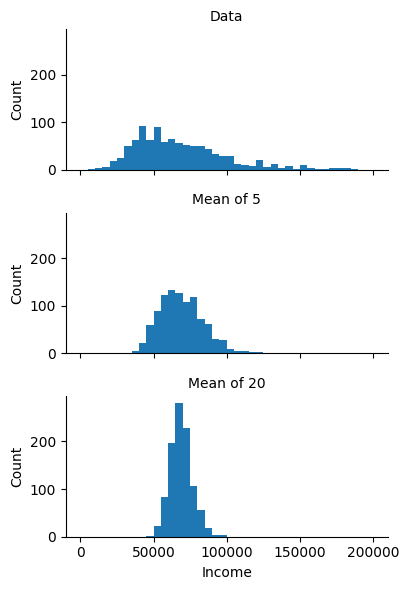

In [ ]:
g = sns.FacetGrid(
    results,
    col='type',
    col_wrap=1,
    height=2,
    aspect=2
)

g.map(
    plt.hist,
    'income',
    range=[0, 200000],
    bins=40
)

g.set_axis_labels('Income', 'Count')
g.set_titles('{col_name}')

plt.show()

### Analisis

Distribusi `Data` menunjukkan variasi income individual.

Distribusi `Mean of 5` lebih terkonsentrasi karena setiap nilai merupakan rata-rata dari 5 data.

Distribusi `Mean of 20` semakin terkonsentrasi karena setiap nilai merupakan rata-rata dari 20 data.

Hal ini menunjukkan bahwa semakin besar ukuran sample, variasi sample mean semakin kecil.

## 4.4 Central Limit Theorem

Central Limit Theorem (CLT) menjelaskan kecenderungan sampling distribution dari sample mean untuk mendekati bentuk distribusi normal ketika ukuran sample semakin besar.

Hal ini dapat terjadi walaupun data awal tidak memiliki distribusi normal.

Secara sederhana:

Sample semakin besar
→ sample mean semakin stabil
→ sampling distribution semakin mendekati distribusi normal.

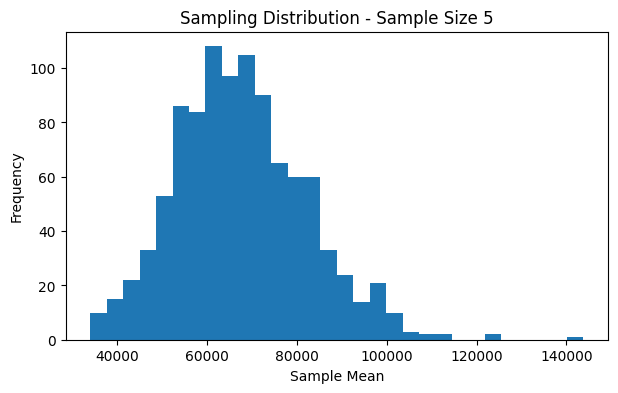

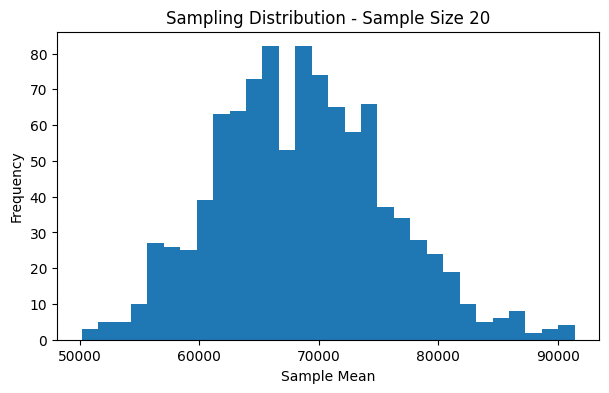

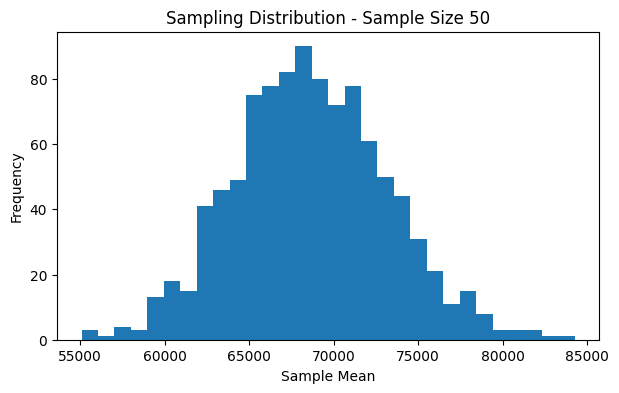

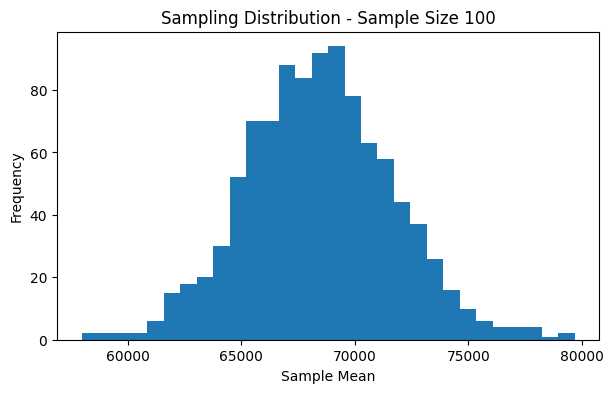

In [ ]:
sample_sizes = [5, 20, 50, 100]

for size in sample_sizes:
    means = [
        loans_income.sample(size).mean()
        for _ in range(1000)
    ]

    plt.figure(figsize=(7, 4))
    plt.hist(means, bins=30)

    plt.title(
        f'Sampling Distribution - Sample Size {size}'
    )
    plt.xlabel('Sample Mean')
    plt.ylabel('Frequency')

    plt.show()

### Analisis

Ketika ukuran sample semakin besar, distribusi sample mean cenderung menjadi lebih terpusat dan berbentuk lebih mendekati distribusi normal.

Hal ini menunjukkan bagaimana Central Limit Theorem membantu menjelaskan perilaku sample mean ketika sampling dilakukan berulang kali.

## 4.5 Standard Error

Standard error digunakan untuk mengukur variasi suatu sample statistic.

Untuk sample mean, standard error dapat diperkirakan menggunakan:

SE = s / √n

dengan:

s = standard deviation sample
n = ukuran sample

Semakin besar ukuran sample, standard error semakin kecil.

Hal ini menunjukkan bahwa estimasi sample mean menjadi semakin stabil ketika jumlah data bertambah.

In [ ]:
for n in [10, 50, 100, 500, 1000]:
    sample = loans_income.sample(n)

    se = sample.std() / np.sqrt(n)

    print(f'n = {n}, Standard Error = {se:.2f}')

n = 10, Standard Error = 10479.93
n = 50, Standard Error = 5383.62
n = 100, Standard Error = 3135.98
n = 500, Standard Error = 1510.71
n = 1000, Standard Error = 1008.47


### Analisis

Hasil menunjukkan bahwa standard error cenderung semakin kecil ketika ukuran sample semakin besar.

Hal ini menunjukkan bahwa peningkatan jumlah sample dapat mengurangi variasi estimasi sample mean.

### 4.5.1 Standard Deviation vs Standard Error

Standard deviation mengukur penyebaran nilai individual dalam suatu data.

Standard error mengukur variasi suatu sample statistic ketika proses sampling dilakukan berulang kali.

Dengan demikian:

Standard Deviation
→ variasi data individual

Standard Error
→ variasi estimasi statistik

## 4.6 The Bootstrap

Bootstrap merupakan metode resampling yang menggunakan data sample yang sudah tersedia untuk membuat sample baru.

Pada bootstrap, sampling dilakukan dengan replacement.

Setiap sample hasil bootstrap digunakan untuk menghitung statistik yang ingin dianalisis.

Bootstrap dapat digunakan untuk memperkirakan:

- Sampling distribution
- Standard error
- Confidence interval

Bootstrap tidak membuat data baru dari population. Metode ini menggunakan kembali data yang tersedia melalui proses sampling dengan replacement.

In [ ]:
#4.6.1 Membuat Bootstrap
#Kita gunakan sample income berukuran 100.
sample = loans_income.sample(
    100,
    random_state=42
)

sample.head()

,x
33553,92000
9427,50000
199,40000
12447,95000
39489,135000


In [ ]:
#Sekarang lakukan bootstrap.
results_bootstrap = []

for _ in range(1000):
    bootstrap_sample = sample.sample(
        len(sample),
        replace=True
    )

    results_bootstrap.append(
        bootstrap_sample.median()
    )

In [ ]:
#Ubah menjadi series
results_bootstrap = pd.Series(results_bootstrap)

In [ ]:
#Hasil
results_bootstrap.head()

,0
0,59763.5
1,50400.0
2,59763.5
3,60239.5
4,58063.5


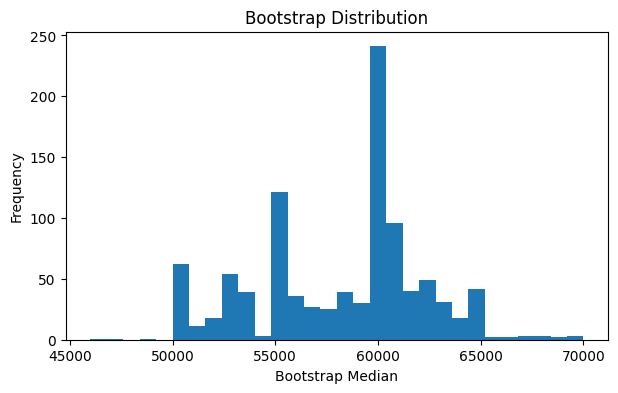

In [ ]:
#4.6.2 Bootstrap Distribution
plt.figure(figsize=(7, 4))

plt.hist(
    results_bootstrap,
    bins=30
)

plt.xlabel('Bootstrap Median')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution')

plt.show()

### Analisis

Histogram menunjukkan distribusi median yang diperoleh dari proses bootstrap.

Setiap nilai pada distribusi berasal dari sample yang dibuat dengan replacement dari sample awal.

Distribusi tersebut dapat digunakan untuk melihat seberapa besar variasi median yang dihasilkan.

### 4.6.3 Resampling vs Bootstrapping

Resampling merupakan istilah umum untuk mengambil sample kembali dari data.

Bootstrapping merupakan salah satu metode resampling yang menggunakan sampling dengan replacement dari sample yang tersedia.

Dengan demikian, bootstrap merupakan salah satu bentuk resampling yang digunakan untuk memperkirakan variasi suatu statistik.

## 4.7 Confidence Intervals

Confidence interval digunakan untuk menyatakan suatu estimasi dalam bentuk rentang nilai.

Confidence interval memiliki confidence level, misalnya:

- 90%
- 95%
- 99%

Semakin tinggi confidence level, biasanya interval yang dihasilkan semakin lebar.

Bootstrap dapat digunakan untuk membuat confidence interval dengan mengambil batas tertentu dari bootstrap distribution.

## 4.8 Normal Distribution

Normal distribution merupakan distribusi berbentuk seperti lonceng atau bell-shaped.

Distribusi normal terutama ditentukan oleh:

- Mean
- Standard deviation

Pada distribusi normal, sekitar 68% data berada dalam satu standard deviation dari mean dan sekitar 95% berada dalam dua standard deviation.

Dalam statistik, distribusi normal sering digunakan sebagai model untuk memahami distribusi data dan sampling statistic.

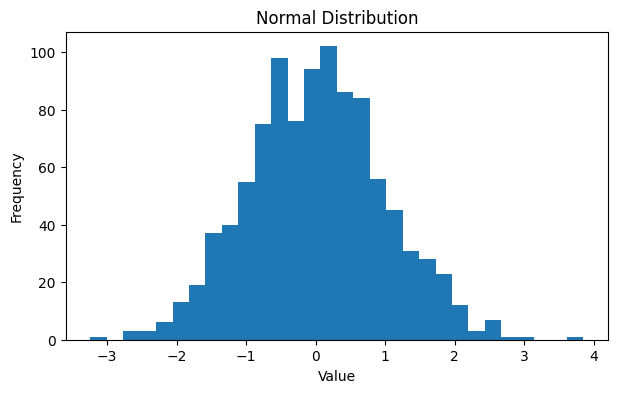

In [ ]:
#Membuat Normal Distribution

normal_data = stats.norm.rvs(
    size=1000,
    random_state=42
)

plt.figure(figsize=(7, 4))

plt.hist(
    normal_data,
    bins=30
)

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Normal Distribution')

plt.show()

## 4.9 Standard Normal and QQ-Plots

Standard normal distribution merupakan distribusi normal dengan:

Mean = 0
Standard deviation = 1

Data dapat distandarisasi menggunakan z-score:

z = (x - mean) / standard deviation

QQ-Plot digunakan untuk membandingkan distribusi data dengan distribusi teoritis, seperti distribusi normal.

Jika titik-titik pada QQ-Plot mengikuti garis lurus, data lebih mendekati distribusi yang dibandingkan.

In [ ]:
#4.9.1 Standard Normal
z = stats.norm.rvs(
    size=100,
    random_state=42
)

print('Mean:', z.mean())
print('Standard deviation:', z.std())


Mean: -0.10384651739409384
Standard deviation: 0.9036161766446296


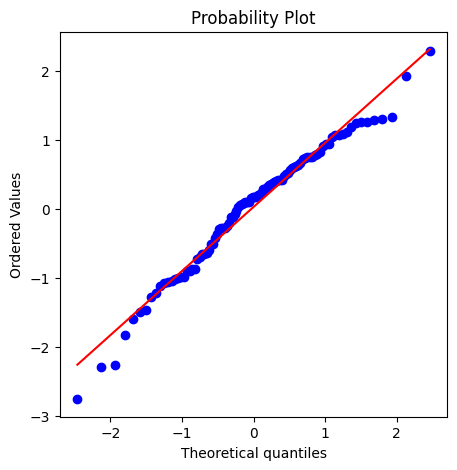

In [ ]:
#4.9.2 QQ-Plot

fig, ax = plt.subplots(figsize=(5, 5))

norm_sample = stats.norm.rvs(
    size=100
)

stats.probplot(
    norm_sample,
    plot=ax
)

plt.show()

### Analisis

Pada QQ-Plot, data yang berasal dari distribusi normal cenderung mengikuti garis lurus.

QQ-Plot dapat digunakan sebagai pemeriksaan visual terhadap kesesuaian data dengan distribusi normal.

##4.10 Long-Tailed Distributions

In [ ]:
sp500_px = pd.read_csv('sp500_data.csv.gz')

In [ ]:
sp500_px = pd.read_csv('sp500_data.csv.gz')

## 4.10 Long-Tailed Distributions

Tidak semua data mengikuti distribusi normal.

Beberapa data memiliki distribusi dengan ekor yang panjang atau long tail.

Long-tailed distribution menunjukkan bahwa terdapat sebagian kecil nilai yang sangat jauh dari sebagian besar data.

Data finansial merupakan salah satu contoh data yang dapat memiliki karakteristik seperti ini.

In [ ]:
nflx = sp500_px.NFLX

nflx = np.diff(
    np.log(nflx[nflx > 0])
)

In [ ]:
nflx = sp500_px.NFLX

nflx = np.diff(
    np.log(nflx[nflx > 0])
)

### Analisis

QQ-Plot menunjukkan bahwa data return tidak sepenuhnya mengikuti distribusi normal.

Beberapa nilai berada jauh dari pola utama sehingga menunjukkan adanya ekor distribusi yang lebih panjang.

Hal ini menunjukkan bahwa data dunia nyata dapat memiliki distribusi yang berbeda dari distribusi normal.

# 5. Summary dan Kesimpulan

## Summary

Chapter 2 membahas bagaimana data diperoleh melalui proses sampling dan bagaimana variasi sample dapat dipahami menggunakan sampling distribution.

Random sampling digunakan untuk memperoleh sample dari population. Dalam proses tersebut, kualitas dan representativeness data perlu diperhatikan karena sample bias dan selection bias dapat menyebabkan sample tidak menggambarkan population dengan baik.

Sampling distribution digunakan untuk melihat distribusi suatu statistik yang diperoleh dari banyak sample. Melalui contoh income, dapat dilihat bahwa sample mean memiliki penyebaran yang lebih kecil ketika ukuran sample semakin besar.

Central Limit Theorem menjelaskan bahwa sampling distribution dari sample mean cenderung mendekati distribusi normal ketika ukuran sample cukup besar.

Standard error digunakan untuk mengukur variasi suatu sample statistic. Semakin besar ukuran sample, standard error cenderung semakin kecil sehingga estimasi menjadi lebih stabil.

Bootstrap merupakan metode resampling dengan replacement yang dapat digunakan untuk memperkirakan variasi suatu statistik. Dari bootstrap distribution, standard error dan confidence interval dapat diperkirakan.

Normal distribution digunakan sebagai distribusi referensi dalam banyak konsep statistik. Standard normal memiliki mean 0 dan standard deviation 1, sedangkan QQ-Plot dapat digunakan untuk membandingkan distribusi data dengan distribusi teoritis.

Namun, data mentah tidak selalu mengikuti distribusi normal. Long-tailed distribution menunjukkan bahwa data dapat memiliki nilai ekstrem yang lebih sering dibandingkan yang diperkirakan oleh distribusi normal.

## Kesimpulan

Dari Chapter 2 dapat dipahami bahwa proses pengambilan sample memiliki pengaruh terhadap hasil analisis statistik. Oleh karena itu, analisis tidak hanya memperhatikan jumlah data, tetapi juga cara data tersebut diperoleh dan seberapa baik sample mewakili population.

Sampling distribution, Central Limit Theorem, dan standard error membantu memahami variasi dari suatu estimasi. Bootstrap memberikan pendekatan resampling untuk mempelajari ketidakpastian berdasarkan data yang tersedia.

Selain itu, normal distribution dan QQ-Plot dapat digunakan sebagai alat untuk memahami bentuk distribusi data. Namun, data dunia nyata tidak selalu berdistribusi normal sehingga karakteristik seperti skew dan long tail juga perlu diperhatikan.

Secara keseluruhan, Chapter 2 memberikan dasar untuk memahami hubungan antara population, sample, sampling variability, dan distribusi data dalam proses analisis statistik.